<a href="https://colab.research.google.com/github/esatsglm/Esat_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [5]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "/"   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [ ]:
# how many rows, which columns, what types?
students.info()

# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

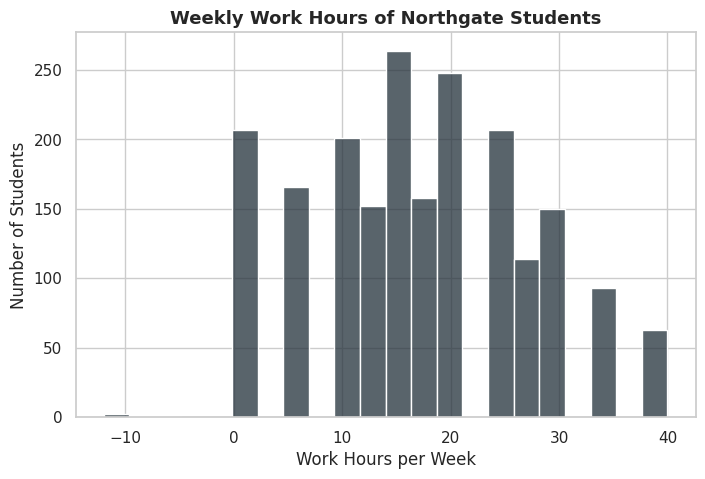

In [6]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

#

fig, ax = plt.subplots()

sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)

ax.set_title("Weekly Work Hours of Northgate Students")
ax.set_xlabel("Work Hours per Week")
ax.set_ylabel("Number of Students")

plt.show()


The histogram shows how many hours Northgate students work per week. A typical student works around 18 hours per week, and the middle half of students work between about 10 and 25 hours. Work hours are fairly spread out, ranging from 0 to 40 hours for most realistic observations. However, there are four negative values, including values as low as -12 hours, which are not realistic and likely represent data-entry errors. These values should be checked or cleaned before using work hours in further analysis.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

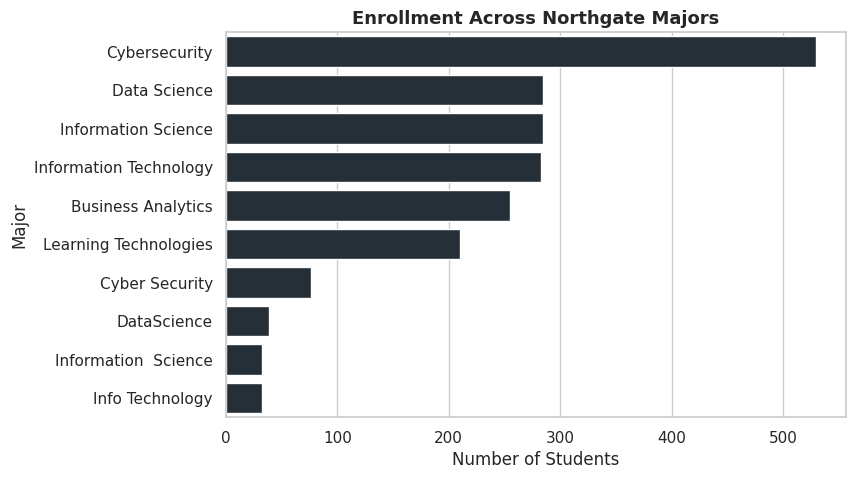

In [10]:
order = students["major"].value_counts().index

fig, ax = plt.subplots()

sns.countplot(data=students, y="major", order=order, color=NAVY, ax=ax)

ax.set_title("Enrollment Across Northgate Majors")
ax.set_xlabel("Number of Students")
ax.set_ylabel("Major")

plt.show()


The bar chart compares enrollment across Northgate majors. Cybersecurity has the largest enrollment by a clear margin, while Data Science, Information Science, and Information Technology have similar enrollment levels. Business Analytics and Learning Technologies have somewhat fewer students. The chart also reveals inconsistent major names, such as “Cybersecurity” and “Cyber Security” and “Data Science” and “DataScience.” These labels may refer to the same majors and should be standardized before making final enrollment comparisons.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

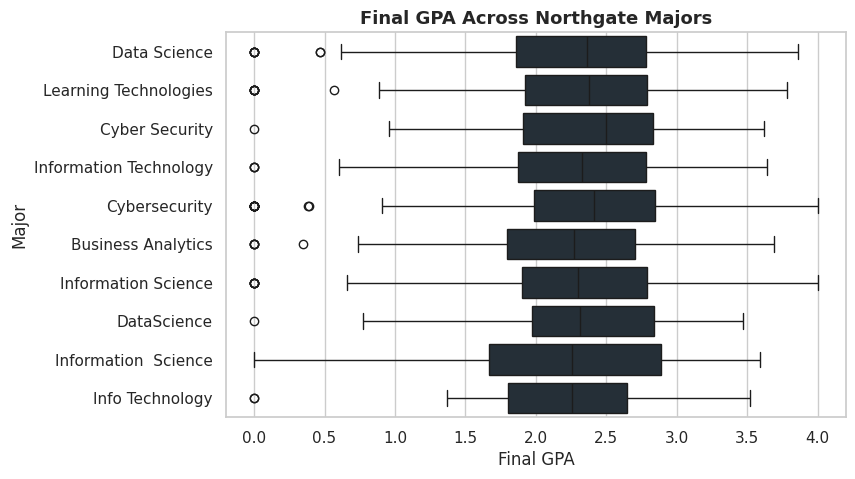

In [11]:
fig, ax = plt.subplots()

sns.boxplot(data=students, x="final_gpa", y="major", color=NAVY, ax=ax)

ax.set_title("Final GPA Across Northgate Majors")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")

plt.show()


The box plots compare final GPA distributions across Northgate majors. The median GPAs are fairly similar across most majors, generally ranging from about 2.3 to 2.5, and the boxes overlap considerably. This suggests that there is not a large difference in typical GPA across majors. However, several majors contain students with a final GPA of 0, which stand out from the rest of the observations. The chart also shows inconsistent major labels, such as “Cybersecurity” and “Cyber Security,” which should be standardized before making stronger comparisons between majors.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

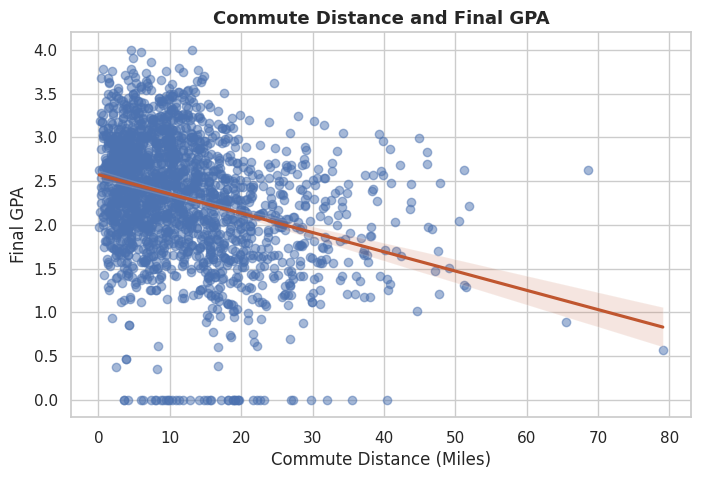

In [12]:
fig, ax = plt.subplots()

sns.regplot(
    data=students,
    x="commute_miles",
    y="final_gpa",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": RUST},
    ax=ax
)

ax.set_title("Commute Distance and Final GPA")
ax.set_xlabel("Commute Distance (Miles)")
ax.set_ylabel("Final GPA")

plt.show()


The scatterplot shows the relationship between commute distance and final GPA for Northgate students. The overall trend is negative, meaning students with longer commutes tend to have lower GPAs on average. However, the points are widely scattered, so commute distance does not perfectly predict GPA. There are also several students with a final GPA of 0 and a few students with very long commutes, which stand out from the rest of the data. This chart shows an association, but it does not prove that longer commutes cause lower GPAs.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

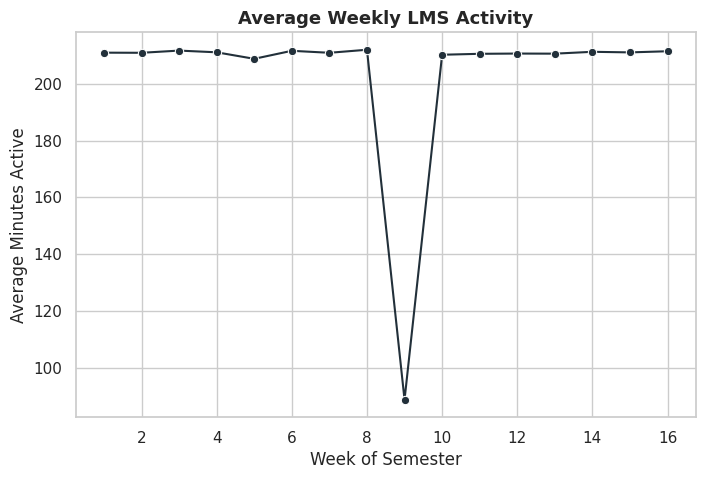

In [13]:
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()

fig, ax = plt.subplots()

sns.lineplot(
    data=weekly_avg,
    x="week",
    y="minutes_active",
    color=NAVY,
    marker="o",
    ax=ax
)

ax.set_title("Average Weekly LMS Activity")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average Minutes Active")

plt.show()


The line chart shows the average number of minutes Northgate students were active in the LMS each week of the semester. Student engagement remains very stable at around 210 minutes per week for most of the semester. However, Week 9 shows a sharp drop to below 100 minutes before activity returns to its usual level in Week 10. This sudden decrease is unusual and should be investigated to determine whether it was caused by a break, a schedule change, or a data-quality issue.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

Do students who dropped out report different study hours than students who stayed enrolled?



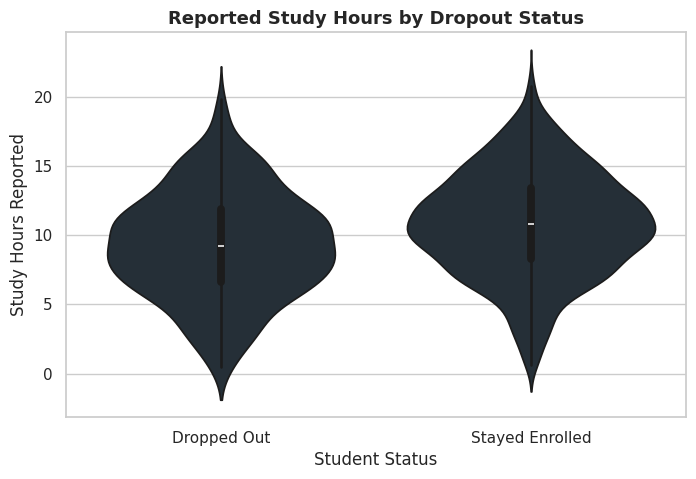

In [14]:
part_b = students.copy()

part_b["dropout_status"] = part_b["dropped_out"].map({
    0: "Stayed Enrolled",
    1: "Dropped Out"
})

fig, ax = plt.subplots()

sns.violinplot(
    data=part_b,
    x="dropout_status",
    y="study_hours_reported",
    color=NAVY,
    ax=ax
)

ax.set_title("Reported Study Hours by Dropout Status")
ax.set_xlabel("Student Status")
ax.set_ylabel("Study Hours Reported")

plt.show()


The violin plot compares reported study hours between students who dropped out and students who stayed enrolled. Students who stayed enrolled generally report slightly more study time, with a typical value around 11 hours compared with about 9 hours for students who dropped out. However, the two distributions overlap considerably, so study hours alone do not clearly separate the two groups. Some study-hour values are also missing from the data, so the comparison does not include every student. This suggests an association between study time and dropout status, but it does not show that lower study time causes students to drop out.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.